In [21]:
import pandas as pd
import numpy as np
import random
import os
import re
import warnings
import matplotlib.pyplot as plt

# --- 모델 및 튜닝 라이브러리 임포트 ---
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

In [22]:
CSV_PATH = '/Users/woojin/Desktop/복분자/BukBunJa_GraduationWork-woojin/server/data/lotto_data_for_db.csv' 
if not os.path.exists(CSV_PATH):
    print(f"경고: '{CSV_PATH}' 경로에 파일이 없습니다. 기본 경로 './lotto_data_for_db.csv'로 시도합니다.")
    CSV_PATH = './lotto_data_for_db.csv'
assert os.path.exists(CSV_PATH), f'CSV 파일을 찾을 수 없습니다: {CSV_PATH}'

df = pd.read_csv(CSV_PATH)

# CSV 파일에서 당첨 번호 6개 컬럼을 자동으로 찾는 함수
def find_number_columns_kor(df_):
    cols = list(df_.columns)
    cand = [f'당첨번호_{i}' for i in range(1, 7)]
    if all(c in cols for c in cand):
        return cand
    pattern_cols = [c for c in cols if re.search(r'당첨.?번호', str(c)) and '보너' not in str(c)]
    if pattern_cols:
        def trailing_num(name):
            m = re.search(r'(\d+)$', str(name))
            return int(m.group(1)) if m else 999
        pattern_cols.sort(key=trailing_num)
        if len(pattern_cols) >= 6:
            return pattern_cols[:6]
    lower = {str(c).lower(): c for c in cols}
    for base in ['drwtno', 'n', 'no', 'num', 'ball', 'col']:
        trial = []
        ok = True
        for i in range(1, 7):
            key = f'{base}{i}'
            if key in lower:
                trial.append(lower[key])
            else:
                ok = False
                break
        if ok:
            return trial
    numlike = []
    for c in cols:
        s = pd.to_numeric(df_[c], errors='coerce')
        if s.notna().mean() < 0.7:
            continue
        rng = ((s >= 1) & (s <= 45)).mean()
        if rng > 0.7:
            numlike.append((c, rng))
    numlike.sort(key=lambda x: x[1], reverse=True)
    if len(numlike) >= 6:
        return [c for c, _ in numlike[:6]]
    raise ValueError(f"당첨번호 6개 컬럼 탐지 실패. 현재 컬럼: {list(df_.columns)}")

num_cols = find_number_columns_kor(df)
nums = df[num_cols].apply(pd.to_numeric, errors='coerce').dropna()
mask = nums.applymap(lambda x: 1 <= x <= 45).all(axis=1)
nums = nums[mask]
draws = nums.apply(lambda r: sorted(map(int, r.values)), axis=1, result_type='expand')
draws.columns = ['n1', 'n2', 'n3', 'n4', 'n5', 'n6']

In [23]:
def primes_upto(n=45):
    sieve = [True] * (n + 1)
    sieve[0] = sieve[1] = False
    for i in range(2, int(n**0.5) + 1):
        if sieve[i]:
            for j in range(i * i, n + 1, i):
                sieve[j] = False
    return {i for i, v in enumerate(sieve) if v}

PRIMES = primes_upto(45)

def corpus_stats(df_draws):
    freq = np.zeros(46)
    last_seen = np.zeros(46) + 9999
    for _, row in df_draws.reset_index(drop=True).iterrows():
        for x in row.values:
            x = int(x)
            freq[x] += 1
            last_seen[x] = 0
        last_seen[last_seen < 9999] += 1
    freq = (freq - freq.mean()) / (freq.std() + 1e-6)
    last_seen = (last_seen - last_seen.mean()) / (last_seen.std() + 1e-6)
    return freq, last_seen

def combo_features(arr, freq, last_seen):
    arr = np.array(arr, dtype=int)
    odds = int(np.sum(arr % 2 == 1))
    total = int(np.sum(arr))
    spread = int(arr[-1] - arr[0])
    consec = int(np.sum(np.diff(arr) == 1))
    low_cnt = int(np.sum(arr <= 22))
    primes = int(np.sum(np.isin(arr, list(PRIMES))))
    freq_sum = float(np.sum(freq[arr]))
    recency = float(np.sum(last_seen[arr]))
    return [odds, total, spread, consec, low_cnt, primes, freq_sum, recency]

freq, last_seen = corpus_stats(draws)
X_pos = [combo_features(np.sort(r.values), freq, last_seen) for _, r in draws.iterrows()]
y_pos = np.ones(len(X_pos), dtype=int)
win_set = {tuple(sorted(map(int, r.values))) for _, r in draws.iterrows()}

def rand_combo():
    return tuple(sorted(random.sample(range(1, 46), 6)))

X_neg = []
while len(X_neg) < len(X_pos) * 10:
    c = rand_combo()
    if c in win_set:
        continue
    X_neg.append(combo_features(np.array(c), freq, last_seen))
y_neg = np.zeros(len(X_neg), dtype=int)
X = np.array(X_pos + X_neg, dtype=float)
y = np.concatenate([y_pos, y_neg])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [24]:
estimators = [
    ('gb', GradientBoostingClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(random_state=42, eval_metric="logloss"))
]
final_estimator = LogisticRegression(random_state=42)
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=3,
    n_jobs=-1
)

# 탐색할 하이퍼파라미터 그리드 정의
param_grid = {
    'gb__n_estimators': [100, 200],
    'gb__max_depth': [3, 5],
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [5, 10],
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5],
    'final_estimator__C': [0.1, 1.0]
}

# GridSearchCV 객체 생성
grid_search = GridSearchCV(
    estimator=stacking_model,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=2,
    n_jobs=-1
)

print("하이퍼파라미터 탐색을 시작합니다. (시간이 오래 걸릴 수 있습니다)")
grid_search.fit(X_train, y_train)

# 최적의 파라미터와 최고 점수 출력
print("\n--- 탐색 결과 ---")
print(f"최고의 파라미터: {grid_search.best_params_}")
print(f"최고 AUC 점수: {grid_search.best_score_:.4f}")
print("-" * 30)

하이퍼파라미터 탐색을 시작합니다. (시간이 오래 걸릴 수 있습니다)
Fitting 3 folds for each of 128 candidates, totalling 384 fits
[CV] END final_estimator__C=0.1, gb__max_depth=3, gb__n_estimators=100, rf__max_depth=5, rf__n_estimators=100, xgb__max_depth=5, xgb__n_estimators=100; total time=   2.8s
[CV] END final_estimator__C=0.1, gb__max_depth=3, gb__n_estimators=100, rf__max_depth=5, rf__n_estimators=100, xgb__max_depth=5, xgb__n_estimators=100; total time=   2.8s
[CV] END final_estimator__C=0.1, gb__max_depth=3, gb__n_estimators=100, rf__max_depth=5, rf__n_estimators=100, xgb__max_depth=5, xgb__n_estimators=100; total time=   2.8s
[CV] END final_estimator__C=0.1, gb__max_depth=3, gb__n_estimators=100, rf__max_depth=5, rf__n_estimators=100, xgb__max_depth=3, xgb__n_estimators=100; total time=   2.8s
[CV] END final_estimator__C=0.1, gb__max_depth=3, gb__n_estimators=100, rf__max_depth=5, rf__n_estimators=100, xgb__max_depth=3, xgb__n_estimators=100; total time=   2.8s
[CV] END final_estimator__C=0.1, gb__max_dep

In [25]:
best_model = grid_search.best_estimator_

weights = {
    "freq": 0.6, "odd_even": 0.5, "sum": 0.5, "spread": 0.3,
    "consec": 0.4, "low_high": 0.4, "recency": 0.3
}
def gen_candidates(k, w, freq, last_seen):
    def weight_score(arr):
        f = combo_features(arr, freq, last_seen)
        score = 0.0
        score += w["freq"] * f[6]
        score -= w["odd_even"] * abs(f[0] - 3)
        if f[1] < 100:
            score -= w["sum"] * (100 - f[1]) / 10
        if f[1] > 170:
            score -= w["sum"] * (f[1] - 170) / 10
        score -= w["consec"] * f[3]
        score -= w["low_high"] * abs(f[4] - 3)
        score += w["recency"] * f[7]
        score += w["spread"] * (f[2] / 44.0)
        return score
    
    seen = set()
    out = []
    while len(out) < k:
        c = tuple(sorted(random.sample(range(1, 46), 6)))
        if c in seen:
            continue
        seen.add(c)
        out.append((c, weight_score(c)))
    
    out.sort(key=lambda x: x[1], reverse=True)
    return [c for c, _ in out]

random.seed(42)
K = 2000
TOPN = 20

cand = gen_candidates(K, weights, freq, last_seen)
feats = [combo_features(np.array(c), freq, last_seen) for c in cand]
probs = best_model.predict_proba(np.array(feats))[:, 1]
ranked = sorted(zip(cand, probs), key=lambda x: x[1], reverse=True)[:TOPN]

pick = random.choice(ranked)
c, p = pick
final_nums_str = ' '.join(map(str, c))

print("--- 최종 추천 번호 (최적화 모델 기반) ---")
for idx, (c, p) in enumerate(ranked, start=1):
    nums = ' '.join(map(str, c))
    print(f"후보 {idx:02}: {nums} (모델 점수={p:.6f})")

print(f"\n✨ 최종 추천: {final_nums_str} (모델 점수={p:.6f})")

--- 최종 추천 번호 (최적화 모델 기반) ---
후보 01: 15 23 29 31 33 42 (모델 점수=0.120902)
후보 02: 14 29 35 40 41 42 (모델 점수=0.109467)
후보 03: 3 4 11 13 17 19 (모델 점수=0.105743)
후보 04: 3 4 5 6 12 17 (모델 점수=0.102801)
후보 05: 7 18 34 40 43 45 (모델 점수=0.101424)
후보 06: 13 17 21 26 27 40 (모델 점수=0.101106)
후보 07: 20 25 33 35 38 43 (모델 점수=0.100068)
후보 08: 7 10 13 14 15 33 (모델 점수=0.100037)
후보 09: 10 16 25 27 29 32 (모델 점수=0.099827)
후보 10: 1 27 30 34 38 40 (모델 점수=0.099059)
후보 11: 3 7 14 33 35 39 (모델 점수=0.098920)
후보 12: 3 31 37 43 44 45 (모델 점수=0.098791)
후보 13: 12 13 16 34 37 43 (모델 점수=0.098731)
후보 14: 13 14 15 16 17 45 (모델 점수=0.098217)
후보 15: 2 7 11 13 14 19 (모델 점수=0.098146)
후보 16: 10 11 27 29 32 33 (모델 점수=0.098123)
후보 17: 5 14 15 36 38 43 (모델 점수=0.098114)
후보 18: 3 5 14 20 27 39 (모델 점수=0.097936)
후보 19: 11 25 35 37 39 41 (모델 점수=0.097910)
후보 20: 24 27 29 31 33 40 (모델 점수=0.097908)

✨ 최종 추천: 10 11 27 29 32 33 (모델 점수=0.097908)



--- 메타 모델이 학습한 모델별 가중치 ---
rf     0.530525
xgb    0.051941
gb    -0.257170
dtype: float64
------------------------------


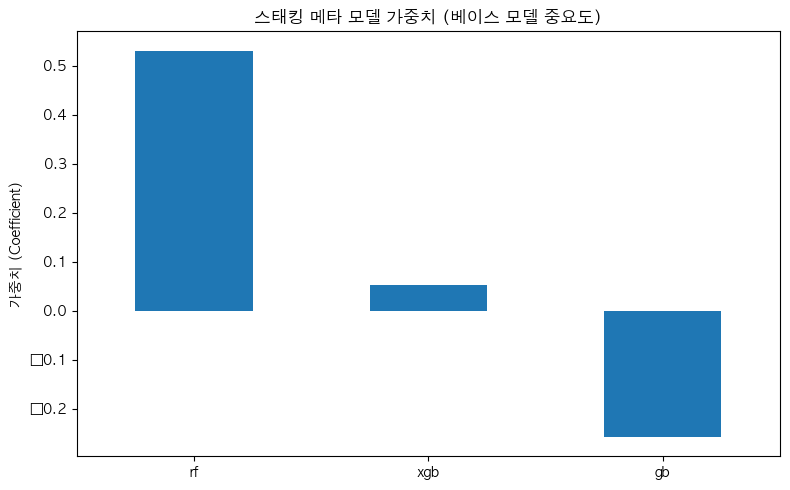

In [26]:
meta_weights = pd.Series(
    model.final_estimator_.coef_[0],
    index=[name for name, _ in estimators]
).sort_values(ascending=False)

print("\n--- 메타 모델이 학습한 모델별 가중치 ---")
print(meta_weights)
print("-" * 30)

# 한글 폰트 설정 (Mac: AppleGothic, Windows: Malgun Gothic)
plt.rc('font', family='AppleGothic')
plt.figure(figsize=(8, 5))
meta_weights.plot(kind='bar')
plt.title("스태킹 메타 모델 가중치 (베이스 모델 중요도)")
plt.ylabel("가중치 (Coefficient)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()